# Compare Forward Tokenizers — char vs WordPiece

Reads the output of `scripts/compare_forward_tokenizers.py` (`raw_results.csv` +
`summary.json`) and, optionally, `scripts/calc_tokenization_stats.py`'s output for the
same AIRR file, and renders the comparison as tables and plots.

Interpretation notes live in markdown cells next to each plot, not on the plots
themselves — the plots only show data (axes, legend identifying which series is which).

In [1]:
# parameters
RESULTS_DIR = "../artifacts/compare_forward_tokenizers_background100k_40epochs_upto30k"
# Optional: output of calc_tokenization_stats.py run on the SAME AIRR file used above,
# with --tokenizers-dir pointing at the same WordPiece tokenizers. Leave as-is if you
# haven't run that diagnostic yet - the relevant section below will just note that.
DOMAIN_TOKENIZATION_STATS_PATH = "../artifacts/tokenizers_1M_integ_on_background100k/tokenization_stats.json"

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_dir = Path(RESULTS_DIR)
raw = pd.read_csv(results_dir / "raw_results.csv")
with open(results_dir / "summary.json") as f:
    summary = json.load(f)

wp = sorted((r for r in summary if r["tokenizer"] == "wordpiece"), key=lambda r: r["vocab_size"])
char_row = next(r for r in summary if r["tokenizer"] == "char")
vocab_sizes = [r["vocab_size"] for r in wp]

print(f"Loaded {len(raw)} individual runs across {len(summary)} tokenizer configs from {results_dir}")
raw.head()

Loaded 18 individual runs across 6 tokenizer configs from ..\artifacts\compare_forward_tokenizers_background100k_40epochs_upto30k


,tokenizer,vocab_size,max_len,seed,test_loss,test_cosine,best_val_loss,epochs_to_best_val,train_time_sec,inference_time_sec,num_parameters,tokenizer_path
0,char,25,40,1,0.202377,0.864400,0.191109,33,1122.731938,0.549614,10850856,NaN
1,char,25,40,42,0.200186,0.866364,0.191719,37,1121.601178,0.565691,10850856,NaN
2,char,25,40,777,0.202525,0.864106,0.199392,36,1122.459536,0.549595,10850856,NaN
3,wordpiece,1000,40,1,0.229882,0.844552,0.224929,36,1142.940060,0.551867,10913256,artifacts/tokenizers_1M_integ/wordpiece_vocab_...
4,wordpiece,1000,40,42,0.233081,0.843024,0.225724,37,1143.059010,0.552772,10913256,artifacts/tokenizers_1M_integ/wordpiece_vocab_...


## Summary table (mean ± std across seeds)

In [3]:
def fmt(mean_std, precision=4):
    mean, std = mean_std
    return f"{mean:.{precision}f} \u00b1 {std:.{precision}f}"

summary_df = pd.DataFrame([
    {
        "tokenizer": row["tokenizer"],
        "vocab_size": row["vocab_size"],
        "test_loss": fmt(row["test_loss"]),
        "test_cosine": fmt(row["test_cosine"]),
        "best_val_loss": fmt(row["best_val_loss"]),
        "epochs_to_best_val": fmt(row["epochs_to_best_val"], precision=1),
        "num_parameters": row["num_parameters"],
        "n_seeds": row["n_seeds"],
    }
    for row in summary
])
summary_df

,tokenizer,vocab_size,test_loss,test_cosine,best_val_loss,epochs_to_best_val,num_parameters,n_seeds
0,char,25,0.2017 ± 0.0013,0.8650 ± 0.0012,0.1941 ± 0.0046,35.3 ± 2.1,10850856,3
1,wordpiece,1000,0.2318 ± 0.0017,0.8439 ± 0.0008,0.2263 ± 0.0017,36.0 ± 1.0,10913256,3
2,wordpiece,5000,0.2695 ± 0.0029,0.8166 ± 0.0021,0.2679 ± 0.0049,39.7 ± 0.6,11169256,3
3,wordpiece,10000,0.3090 ± 0.0032,0.7883 ± 0.0019,0.3077 ± 0.0028,40.0 ± 0.0,11489256,3
4,wordpiece,20000,0.3552 ± 0.0008,0.7559 ± 0.0010,0.3534 ± 0.0032,39.3 ± 1.2,12129256,3
5,wordpiece,30000,0.3774 ± 0.0045,0.7398 ± 0.0040,0.3744 ± 0.0052,37.7 ± 2.1,12769256,3


## 1. test_loss vs vocab_size

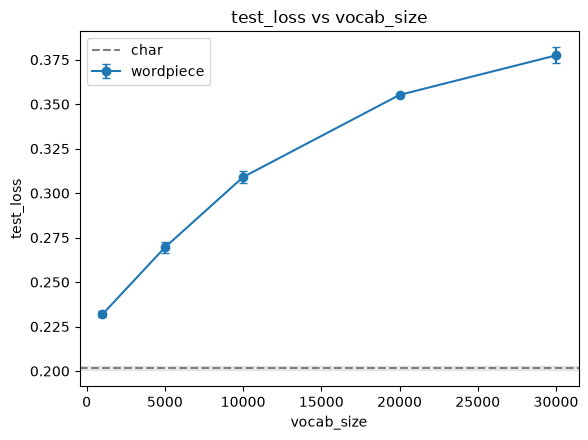

In [4]:
loss_means = [r["test_loss"][0] for r in wp]
loss_stds = [r["test_loss"][1] for r in wp]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.errorbar(vocab_sizes, loss_means, yerr=loss_stds, marker="o", capsize=3, label="wordpiece")
ax.axhline(char_row["test_loss"][0], color="gray", linestyle="--", label="char")
ax.axhspan(char_row["test_loss"][0] - char_row["test_loss"][1],
           char_row["test_loss"][0] + char_row["test_loss"][1], color="gray", alpha=0.15)
ax.set_xlabel("vocab_size")
ax.set_ylabel("test_loss")
ax.set_title("test_loss vs vocab_size")
ax.legend()
plt.tight_layout()
plt.show()

*Notes: lower `test_loss` is better. `char` has no `vocab_size` position of its own — it's
drawn as a horizontal reference (line + shaded std band), not a point on the WordPiece
ablation grid.*

## 2. test_cosine vs vocab_size

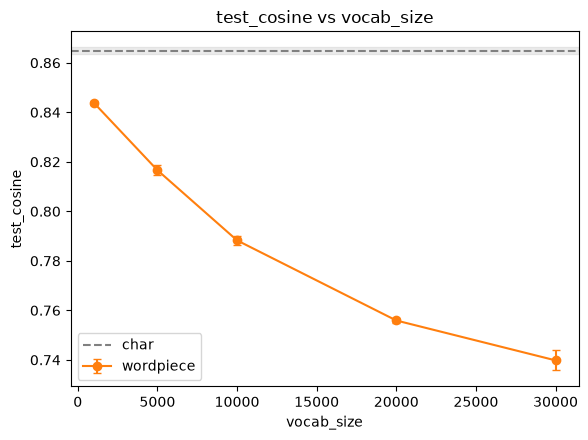

In [5]:
cos_means = [r["test_cosine"][0] for r in wp]
cos_stds = [r["test_cosine"][1] for r in wp]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.errorbar(vocab_sizes, cos_means, yerr=cos_stds, marker="o", capsize=3, color="tab:orange", label="wordpiece")
ax.axhline(char_row["test_cosine"][0], color="gray", linestyle="--", label="char")
ax.axhspan(char_row["test_cosine"][0] - char_row["test_cosine"][1],
           char_row["test_cosine"][0] + char_row["test_cosine"][1], color="gray", alpha=0.15)
ax.set_xlabel("vocab_size")
ax.set_ylabel("test_cosine")
ax.set_title("test_cosine vs vocab_size")
ax.legend()
plt.tight_layout()
plt.show()

*Notes: higher `test_cosine` is better.*

## 3. Per-seed spread of test_loss

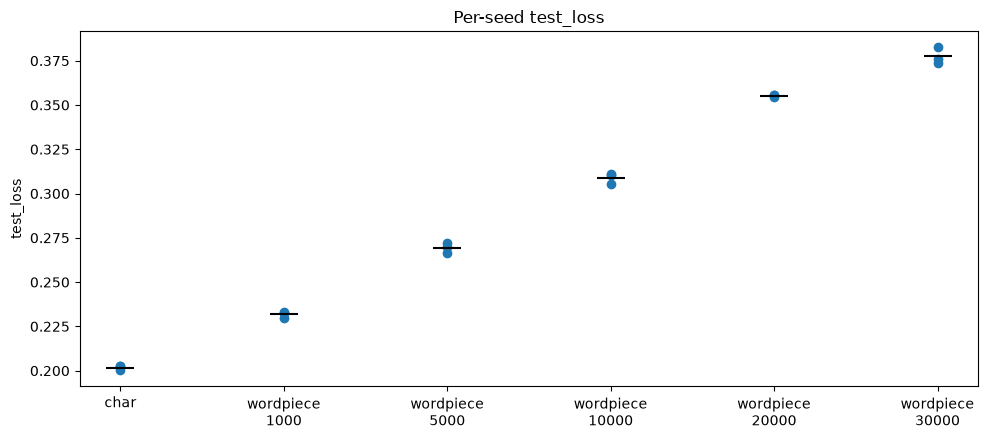

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
configs = sorted(raw[["tokenizer", "vocab_size"]].drop_duplicates().itertuples(index=False),
                  key=lambda c: (c.tokenizer, c.vocab_size))
labels = [f"{c.tokenizer}\n{c.vocab_size}" if c.tokenizer == "wordpiece" else "char" for c in configs]

for i, c in enumerate(configs):
    subset = raw[(raw["tokenizer"] == c.tokenizer) & (raw["vocab_size"] == c.vocab_size)]
    ax.scatter([i] * len(subset), subset["test_loss"], color="tab:blue", zorder=3)
    ax.scatter([i], [subset["test_loss"].mean()], color="black", marker="_", s=400, zorder=4)

ax.set_xticks(range(len(configs)))
ax.set_xticklabels(labels)
ax.set_ylabel("test_loss")
ax.set_title("Per-seed test_loss")
plt.tight_layout()
plt.show()

*Notes: each blue dot is one seed's `test_loss`; the black dash is the mean shown in the
summary table. Useful for checking whether a mean is being pulled around by a single
unusually good/bad seed rather than reflecting all three consistently.*

## 4. best_val_loss vs test_loss, by vocab_size

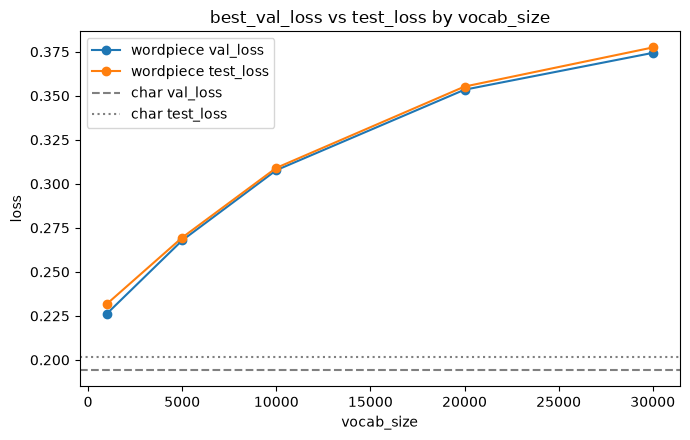

In [7]:
val_means = [r["best_val_loss"][0] for r in wp]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(vocab_sizes, val_means, marker="o", label="wordpiece val_loss")
ax.plot(vocab_sizes, loss_means, marker="o", label="wordpiece test_loss")
ax.axhline(char_row["best_val_loss"][0], color="gray", linestyle="--", label="char val_loss")
ax.axhline(char_row["test_loss"][0], color="gray", linestyle=":", label="char test_loss")
ax.set_xlabel("vocab_size")
ax.set_ylabel("loss")
ax.set_title("best_val_loss vs test_loss by vocab_size")
ax.legend()
plt.tight_layout()
plt.show()

*Notes: a wide, growing gap between the val and test lines for a given tokenizer would
point to overfitting to the validation split (or a val/test distribution mismatch); lines
staying close together across `vocab_size` suggests the ranking in plots 1-2 isn't an
artifact of overfitting.*

## 5. epochs_to_best_val, by config

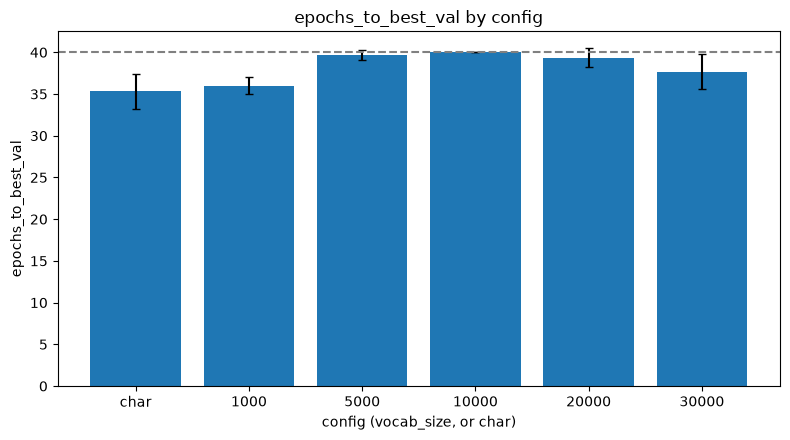

In [8]:
inferred_total_epochs = int(raw["epochs_to_best_val"].max())

conv = (
    raw.groupby(["tokenizer", "vocab_size"])["epochs_to_best_val"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(["tokenizer", "vocab_size"])
)
conv_labels = ["char" if t == "char" else str(int(v)) for t, v in zip(conv["tokenizer"], conv["vocab_size"])]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(conv_labels, conv["mean"], yerr=conv["std"].fillna(0), capsize=3)
ax.axhline(inferred_total_epochs, color="gray", linestyle="--")
ax.set_xlabel("config (vocab_size, or char)")
ax.set_ylabel("epochs_to_best_val")
ax.set_title("epochs_to_best_val by config")
plt.tight_layout()
plt.show()

*Notes: the dashed line marks the last epoch of the run (`--epochs` used). A bar
reaching that line means best `val_loss` landed on the final epoch for at least some
seeds — i.e. training may not have plateaued yet for that config. See the per-seed
breakdown below for exactly how many of the 3 seeds hit that ceiling per config.*

In [9]:
def summarize_convergence(group):
    hit_ceiling = int((group["epochs_to_best_val"] == inferred_total_epochs).sum())
    return pd.Series({"seeds_hitting_ceiling": hit_ceiling, "n_seeds": len(group)})

ceiling_df = (
    raw.groupby(["tokenizer", "vocab_size"])
    .apply(summarize_convergence, include_groups=False)
    .reset_index()
)
ceiling_df["fraction_hitting_ceiling"] = ceiling_df["seeds_hitting_ceiling"] / ceiling_df["n_seeds"]
ceiling_df.sort_values("fraction_hitting_ceiling", ascending=False)

,tokenizer,vocab_size,seeds_hitting_ceiling,n_seeds,fraction_hitting_ceiling
3,wordpiece,10000,3,3,1.000000
2,wordpiece,5000,2,3,0.666667
4,wordpiece,20000,2,3,0.666667
5,wordpiece,30000,1,3,0.333333
1,wordpiece,1000,0,3,0.000000
0,char,25,0,3,0.000000


## 6. num_parameters vs test_loss

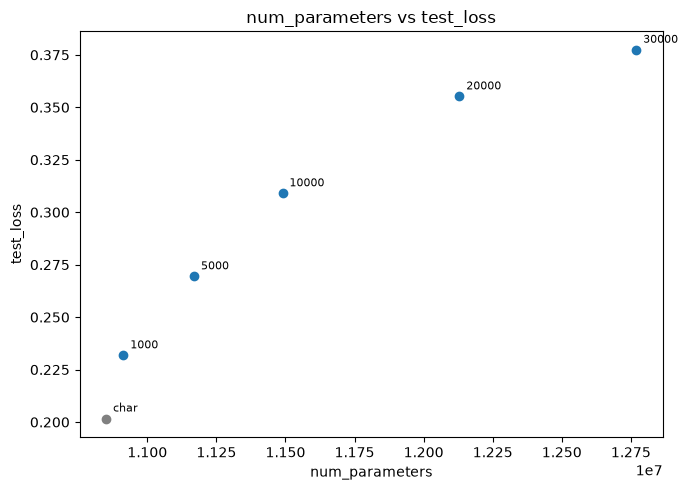

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
for row in summary:
    label = "char" if row["tokenizer"] == "char" else str(row["vocab_size"])
    ax.scatter(row["num_parameters"], row["test_loss"][0],
               color="gray" if row["tokenizer"] == "char" else "tab:blue")
    ax.annotate(label, (row["num_parameters"], row["test_loss"][0]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.set_xlabel("num_parameters")
ax.set_ylabel("test_loss")
ax.set_title("num_parameters vs test_loss")
plt.tight_layout()
plt.show()

*Notes: point labels identify which config each point is (`char`, or the WordPiece
`vocab_size`) - this is identification, not an interpretive claim. `char` has fewer
parameters than every WordPiece config here (smaller embedding table), which is worth
keeping in mind when comparing this plot against plots 1-2.*

## 7. train_time_sec by config

In [11]:
median_time = raw["train_time_sec"].median()
raw["time_ratio_vs_median"] = raw["train_time_sec"] / median_time
outliers = raw[raw["time_ratio_vs_median"] > 3]
clean = raw[raw["time_ratio_vs_median"] <= 3]

if len(outliers):
    print(f"Excluding {len(outliers)} run(s) with train_time_sec > 3x the median "
          f"(likely contaminated by something external, e.g. the machine sleeping mid-run):")
    print(outliers[["tokenizer", "vocab_size", "seed", "train_time_sec", "time_ratio_vs_median"]].to_string(index=False))

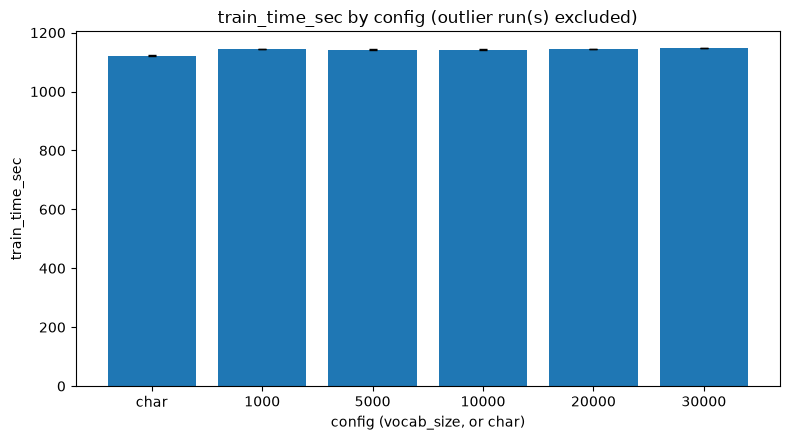

In [12]:
time_stats = (
    clean.groupby(["tokenizer", "vocab_size"])["train_time_sec"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(["tokenizer", "vocab_size"])
)
time_labels = ["char" if t == "char" else str(int(v)) for t, v in zip(time_stats["tokenizer"], time_stats["vocab_size"])]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(time_labels, time_stats["mean"], yerr=time_stats["std"].fillna(0), capsize=3)
ax.set_xlabel("config (vocab_size, or char)")
ax.set_ylabel("train_time_sec")
ax.set_title("train_time_sec by config (outlier run(s) excluded)")
plt.tight_layout()
plt.show()

## 8. unk_token_fraction vs vocab_size, on this AIRR file

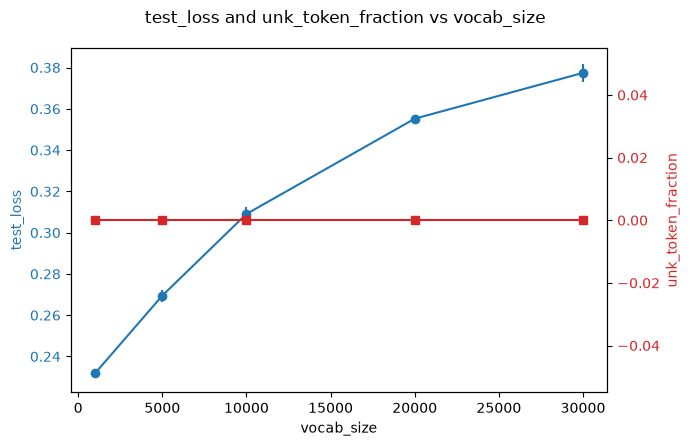

In [13]:
domain_stats_path = Path(DOMAIN_TOKENIZATION_STATS_PATH)

if not domain_stats_path.exists():
    print(f"Not found: {domain_stats_path}")
    print("Run scripts/calc_tokenization_stats.py on the same AIRR file used for the "
          "results above (pointed at the same --tokenizers-dir) to produce this file, "
          "then re-run this cell.")
else:
    with open(domain_stats_path) as f:
        domain_stats = json.load(f)
    per_vocab_size = domain_stats["per_vocab_size"]

    domain_vocab_sizes = [vs for vs in vocab_sizes if str(vs) in per_vocab_size]
    missing = [vs for vs in vocab_sizes if str(vs) not in per_vocab_size]
    if missing:
        print(f"No tokenization_stats entry for vocab_size={missing}; plotting only {domain_vocab_sizes}.")

    unk_fractions = [per_vocab_size[str(vs)]["splits"]["test"]["unk_token_fraction"] for vs in domain_vocab_sizes]

    fig, ax1 = plt.subplots(figsize=(7, 4.5))
    ax1.errorbar(vocab_sizes, loss_means, yerr=loss_stds, marker="o", color="tab:blue", label="test_loss")
    ax1.set_xlabel("vocab_size")
    ax1.set_ylabel("test_loss", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    ax2.plot(domain_vocab_sizes, unk_fractions, marker="s", color="tab:red", label="unk_token_fraction (test split)")
    ax2.set_ylabel("unk_token_fraction", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    fig.suptitle("test_loss and unk_token_fraction vs vocab_size")
    fig.tight_layout()
    plt.show()

*Notes: `unk_token_fraction` here comes from running the WordPiece tokenizers on THIS
AIRR file's own test split (via `calc_tokenization_stats.py`), separately from the model
training run above. If this line rises steeply with `vocab_size` on this file - more so
than what `tokenizer_stats_report.ipynb` shows for the file the tokenizers were originally
trained on - that supports a domain-mismatch explanation for plots 1-2 rather than a
WordPiece-architecture explanation. If it stays flat/low, domain mismatch is less likely
to be the cause and the effect in plots 1-2 is more likely something else (e.g. see plot 5
for a convergence-based explanation).*